%md
# QTL-Level Modeling of Phenotype Using PLSR

This notebook investigates the relationship between genetic variation (QTL/loci) and phenotypic traits (e.g., VOC profiles) using Partial Least Squares Regression (PLSR).

Genotype and phenotype datasets are first aligned and preprocessed to ensure consistency across samples. A PLSR model is then trained to identify latent components that capture the maximal covariance between genetic markers and phenotypic traits.

The analysis aims to:

* Predict phenotypic variation from genetic data
* Identify key loci contributing to trait variation
* Quantify how well genetic information explains phenotype

This approach provides a predictive framework for linking genetic architecture to metabolomic traits.


# Loading plsr module

In [0]:
import os
import sys
import importlib
import yaml

# ----------------------------
# Path to module
# ----------------------------
MODULE_PATH = "/Volumes/bmqg/default_bronze/fatemeh/final_project/modules"

plsr_file = os.path.join(MODULE_PATH, "PLSR.py")

assert os.path.exists(plsr_file), f"PLSR.py not found: {plsr_file}"

# ----------------------------
# Add module path to Python path
# ----------------------------
if MODULE_PATH not in sys.path:
    sys.path.insert(0, MODULE_PATH)

# ----------------------------
# Import module
# ----------------------------
import PLSR

# reload (important when editing module)
importlib.reload(PLSR)

print("PLSR module loaded from:")
print(PLSR.__file__)

PLSR module loaded from:
/Volumes/bmqg/default_bronze/fatemeh/final_project/modules/PLSR.py


In [0]:


# ------------------------------------------------------------
# LOAD CONFIG
# ------------------------------------------------------------
CONFIG_PATH = "/Volumes/bmqg/default_bronze/fatemeh/config_mixed.yaml"

with open(CONFIG_PATH, "r") as f:
    CONFIG = yaml.safe_load(f)

print("Config loaded")

# force pipeline to use new harvested GWAS
CONFIG["data"]["gwas_table"] = CONFIG["data"]["gwas_table_newharvested"]

GWAS_TABLE = CONFIG["data"]["gwas_table"]
TAGLO_TABLE = CONFIG["paths"]["TAGLO_TABLE"]

print("GWAS table used:", GWAS_TABLE)

PHENO_PATH = CONFIG["paths"]["aroma_matrix_newharvested"]
pheno = pd.read_csv(PHENO_PATH)

# ------------------------------------------------------------
# 3) OUTPUT DIRECTORY
# ------------------------------------------------------------
OUT_DIR = "/Volumes/bmqg/default_bronze/fatemeh/final_project/plsr_newharvested"
os.makedirs(OUT_DIR, exist_ok=True)

PLOT_DIR = os.path.join(OUT_DIR, "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

# IMPORTANT: define output path where module expects it
CONFIG.setdefault("paths", {})
CONFIG["paths"]["plsr_out_dir"] = OUT_DIR

print("Output directory:", OUT_DIR)

# ------------------------------------------------------------
# 4) RUN PLSR PIPELINE
# ------------------------------------------------------------
print("\nRunning PLSR pipeline...")

res = PLSR.run_fast_plsr_pipeline(
    spark=spark,
    config=CONFIG,
    drop_ch00=True,
    make_plots=True
)

print("PLSR pipeline finished")

# ------------------------------------------------------------
# 5) SHOW RESULTS
# ------------------------------------------------------------
if "all_top" in res:
    print("\nTop results:")
    display(res["all_top"].head(20))

if "out_csv" in res:
    print("\nResults saved to:")
    print(res["out_csv"])

print("\nPipeline complete")

Loaded PLSR module from:
/Volumes/bmqg/default_bronze/fatemeh/final_project/modules/PLSR.py
Config loaded
GWAS table used: bmqg.gwas.run_local_20260305_newharvested
Output directory: /Volumes/bmqg/default_bronze/fatemeh/final_project/plsr_newharvested

Running PLSR pipeline...
[run_fast_plsr_pipeline] Using GWAS table: bmqg.gwas.run_local_20260305_newharvested
Signed matrix rows: 38
Signed matrix columns: 102
PLSR pipeline finished

Top results:


QTL_id,loading,abs,trait
ST4.03ch11_GQTL1,0.21014775991963414,0.21014775991963414,Eucalyptol
ST4.03ch07_GQTL15,0.20301308077135796,0.20301308077135796,Eucalyptol
ST4.03ch01_GQTL15,0.19493498498395168,0.19493498498395168,Eucalyptol
ST4.03ch05_GQTL4,0.19368507735639287,0.19368507735639287,Eucalyptol
ST4.03ch07_GQTL16,0.19224486462120455,0.19224486462120455,Eucalyptol
ST4.03ch04_GQTL7,0.18984520092114396,0.18984520092114396,Eucalyptol
ST4.03ch08_GQTL2,0.18826474039692281,0.18826474039692281,Eucalyptol
ST4.03ch02_GQTL7,0.18349244227180558,0.18349244227180558,Eucalyptol
ST4.03ch05_GQTL6,0.1820479756134299,0.1820479756134299,Eucalyptol
ST4.03ch12_GQTL14,0.17406684610247497,0.17406684610247497,Eucalyptol



Results saved to:
/Volumes/bmqg/default_bronze/fatemeh/final_project/plsr_newharvested/plsr_top_loadings_fast.csv

Pipeline complete


In [0]:
import pandas as pd

# load file
df = pd.read_csv("/Volumes/bmqg/default_bronze/fatemeh/final_project/plsr_newharvested/plsr_top_loadings_fast.csv")

# extract chromosome from QTL_id
df["chrom"] = df["QTL_id"].str.extract(r'ch(\d+)')

# optional: convert to int for sorting
df["chrom"] = df["chrom"].astype(int)

# =========================
# 1) importance per chromosome
# =========================
chrom_importance = (
    df.groupby("chrom")["abs"]
      .sum()
      .sort_values(ascending=False)
)

print("Chromosome importance (sum of abs loadings):")
print(chrom_importance)

# =========================
# 2) number of QTLs per chromosome
# =========================
chrom_counts = df["chrom"].value_counts().sort_index()

print("\nQTL count per chromosome:")
print(chrom_counts)

# =========================
# 3) combine both
# =========================
summary = pd.DataFrame({
    "total_importance": chrom_importance,
    "n_QTLs": chrom_counts
}).sort_values("total_importance", ascending=False)

print("\nFinal summary:")
print(summary)

Chromosome importance (sum of abs loadings):
chrom
12    22.309064
7     14.635928
1     13.289599
5     10.645096
8      7.125136
4      6.224685
2      5.738460
11     3.798509
6      1.062854
9      0.971549
10     0.816625
3      0.413085
Name: abs, dtype: float64

QTL count per chromosome:
chrom
1     57
2     27
3      2
4     29
5     47
6      5
7     61
8     31
9      4
10     4
11    16
12    97
Name: count, dtype: int64

Final summary:
       total_importance  n_QTLs
chrom                          
12            22.309064      97
7             14.635928      61
1             13.289599      57
5             10.645096      47
8              7.125136      31
4              6.224685      29
2              5.738460      27
11             3.798509      16
6              1.062854       5
9              0.971549       4
10             0.816625       4
3              0.413085       2


Chromosome-level aggregation of PLSR loadings highlights chromosome 12 as the primary genomic hotspot driving phenotypic variation, with additional contributions from chromosomes 7 and 1, while other chromosomes show relatively minor effects.

# Chromosome-Level Comparison of Genetic Contributions to VOC Variation in New vs. Stored Potato

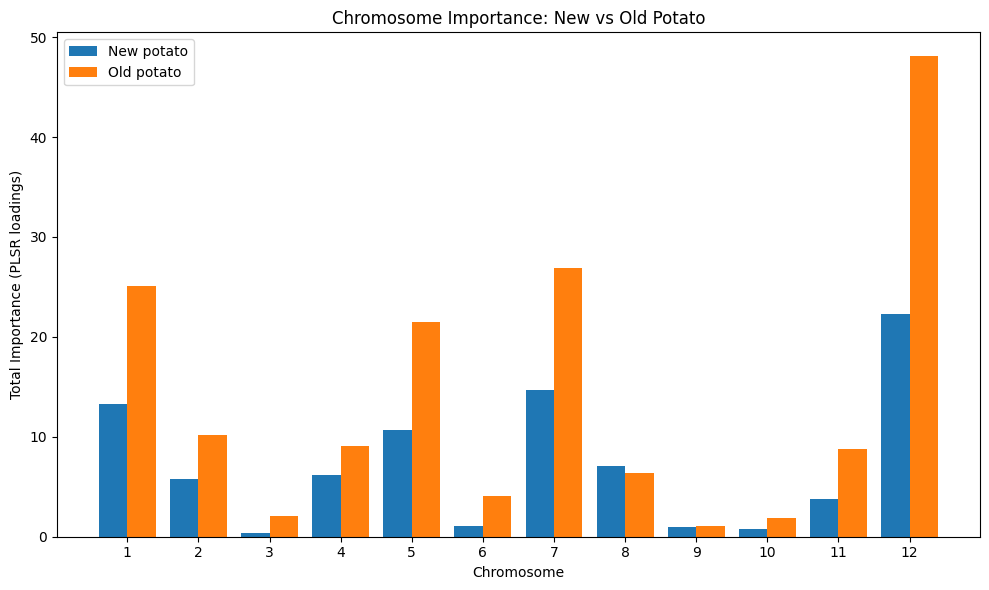

In [0]:


# =========================
# INPUT DATA
# =========================

# new potato
new_data = {
    "chrom": [12,7,1,5,8,4,2,11,6,9,10,3],
    "importance": [22.309064,14.635928,13.289599,10.645096,
                   7.125136,6.224685,5.738460,3.798509,
                   1.062854,0.971549,0.816625,0.413085]
}

# old potato
old_data = {
    "chrom": [12,7,1,5,2,4,11,8,6,3,10,9],
    "importance": [48.077149,26.939610,25.123292,21.456658,
                   10.202893,9.036195,8.773417,6.415619,
                   4.098283,2.070061,1.834829,1.026745]
}

df_new = pd.DataFrame(new_data)
df_old = pd.DataFrame(old_data)

# =========================
# MERGE + SORT
# =========================

df = pd.merge(df_new, df_old, on="chrom", how="outer",
              suffixes=("_new", "_old")).fillna(0)

df = df.sort_values("chrom")

# =========================
# PLOT
# =========================

plt.figure(figsize=(10,6))

x = range(len(df))
width = 0.4

# bars
plt.bar([i - width/2 for i in x], df["importance_new"], width=width, label="New potato")
plt.bar([i + width/2 for i in x], df["importance_old"], width=width, label="Old potato")

# labels
plt.xticks(x, df["chrom"].astype(str))
plt.xlabel("Chromosome")
plt.ylabel("Total Importance (PLSR loadings)")
plt.title("Chromosome Importance: New vs Old Potato")

plt.legend()
plt.tight_layout()

# save (optional)
plt.savefig("new_vs_old_chromosome_importance.png", dpi=200)

plt.show()